### Observation and Visualisations

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [25]:
df = pd.read_csv('train_df.csv')

In [26]:
df.head()

,Unnamed: 0,post_id,emoticon_1,emoticon_2,emoticon_3,if_1,if_2,race,religion,gender,...,votes_ratio,upvote_log1,downvote_log1,engagement_score,emoticon_density,post_comments_count,if_1_log,if_2_log,if_interaction_log,sentiment_vader
0,0,73,0,0,0,0,10,Missing,Missing,Missing,...,0.0,0.000000,0.693147,-1,0.000000,14882,0.0,2.397895,0.0,-0.2023
1,1,39,0,0,0,0,4,Missing,Missing,Missing,...,1.0,1.945910,0.000000,6,0.000000,40946,0.0,1.609438,0.0,0.0258
2,2,31,0,1,1,0,10,Missing,Missing,Missing,...,0.0,0.000000,0.000000,0,0.014925,17023,0.0,2.397895,0.0,-0.9626
3,3,39,0,0,0,0,10,Missing,Missing,Missing,...,1.0,1.791759,0.000000,5,0.000000,40946,0.0,2.397895,0.0,0.0000
4,4,39,0,0,0,0,10,Missing,Missing,Missing,...,0.0,0.000000,0.000000,0,0.000000,40946,0.0,2.397895,0.0,0.5106


<Axes: xlabel='label', ylabel='count'>

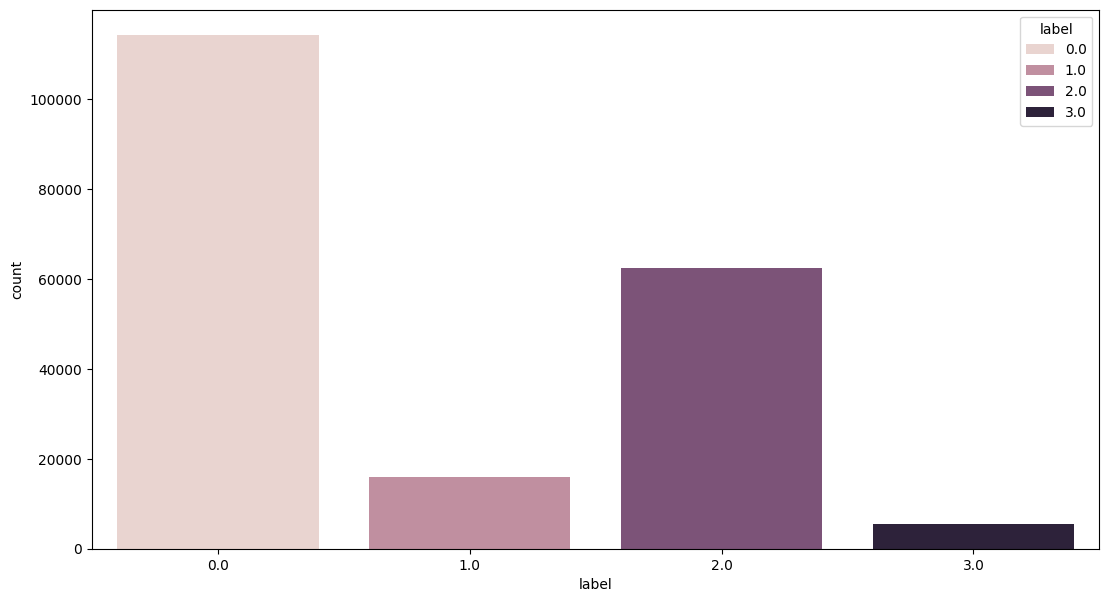

In [12]:
# 
plt.figure(figsize=(13,7))
sns.countplot(x= 'label', data= df, hue='label')

### count vs label
1. massive imbalance
2. 0(>1lkh) >> 2 > 1 >> 3

If we feed this to ml model it'll take path of least resistance hence, Because Label 0.0 and 2.0 make up the vast majority of the data, the model will spend all its time learning how to predict those two and mostly ignore 1.0 and 3.0. it'll guess 0 for every row.. and still achieve over 50% accuracy

#### Data Correction: Resampling
If class weights aren't enough, we can physically alter the dataset before training.

- Undersampling: Randomly deleting rows from 0.0 and 2.0 to match the size of 3.0. (Not recommended here, as you'd throw away 150,000+ rows of good data).

- Oversampling (SMOTE): Synthetic Minority Over-sampling Technique. This algorithm looks at your rare classes (1.0 and 3.0) and mathematically generates new, synthetic data points to bulk them up so the model has enough examples to learn from.

<Axes: xlabel='engagement_score', ylabel='comment_len'>

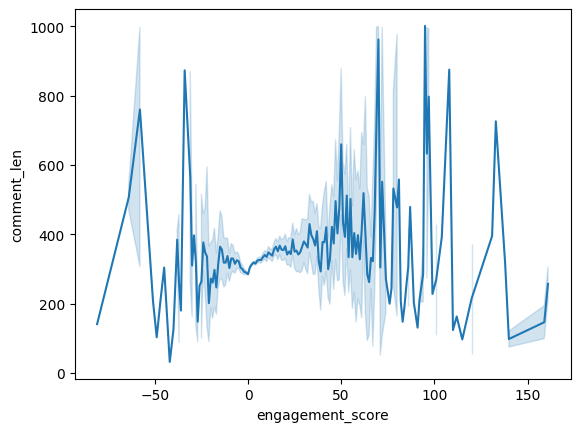

In [13]:
sns.lineplot(x='engagement_score', y='comment_len', data=df)

### Observations: engagement and comment length
1. there's a stable zone between 0-50 with avg comment length ranging between 300-400
2. below -25 and above +75 thel line starts acting wildly and the shaded area which is the confidence interval(seaborn ~95%) gets very wide meaning there are few pointing at extreme scores, thus it doesn't feel like trend more like outliers
3. Note:
    - Narrow Shading: High confidence. You have enough data to be sure the "average" comment length is actually there.

    - Wide/Erratic Shading: Low confidence. The model is guessing based on very thin evidence.

thus most of the users have an engagement score between 0 and 40, and they typically write comments that are 300–350 characters long. The data outside of that range is too thin to find any conclusions from

<Axes: xlabel='label', ylabel='comment_len'>

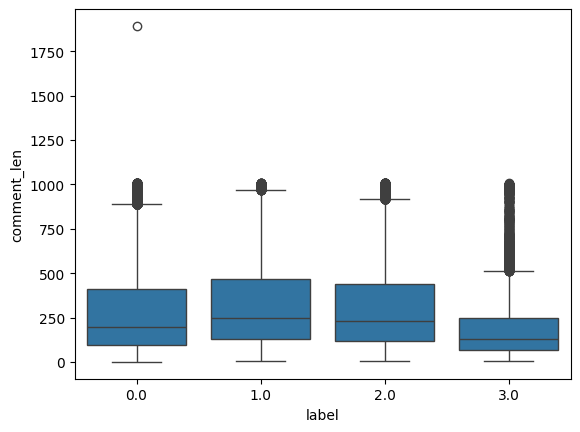

In [45]:
# COMMENTS  length vs label
sns.boxplot(x= 'label', y = 'comment_len', data = df)

<Axes: xlabel='label', ylabel='comment_len'>

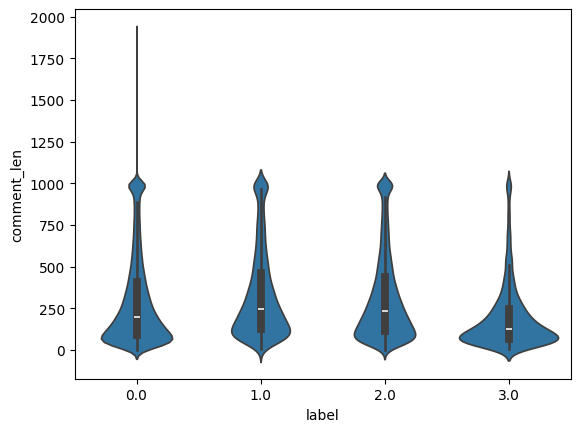

In [82]:
sns.violinplot(x= 'label', y = 'comment_len', data = df)
# sns.boxenplot(x= 'label', y = 'comment_len', data = df)


### Observations: label v/s comment_len 
1. we have 1 outlier comment getting 1900~ len even after plateform limit, probably collected due to error in parsing or wasne't cleaned.
2. the higest label has the lowest comment len
3. Since the labels have an invisible sealing of 1000 words it suggests that the platform or API where we got this data from has hard word limit of 1000
4. Lable 3 is odd one out, it's IQR is significantly lower than other 3 
    - whatever comments category label 3 is for people tend to write it short yet there's strangly high volumne of them that push all the way to plateform limit.



1. 1000 word limit
2. The Missing "Middle Ground"
Look at the "neck" of the violin for Label 1.0 and 2.0 (the area between 500 and 900). It is extremely thin.

- What this means: Human behavior here is highly polarized. Users either write standard, short-to-medium comments (between 50 and 400 length), OR they go completely unhinged and write a massive wall of text that hits the 1000-character cap. Very few people naturally stop typing at exactly 700 characters.

3. Label 3.0's True Shape
- The box plot showed us that Label 3.0 was shorter, but this plot shows us how much shorter.

- Look at how wide the base is for Label 3.0 compared to the others. The vast majority of these comments are incredibly brief (likely under 100 characters).

- Despite this, it still has that tiny little bulge at 1000, meaning a small dedicated group is still spamming the max limit even in this category.

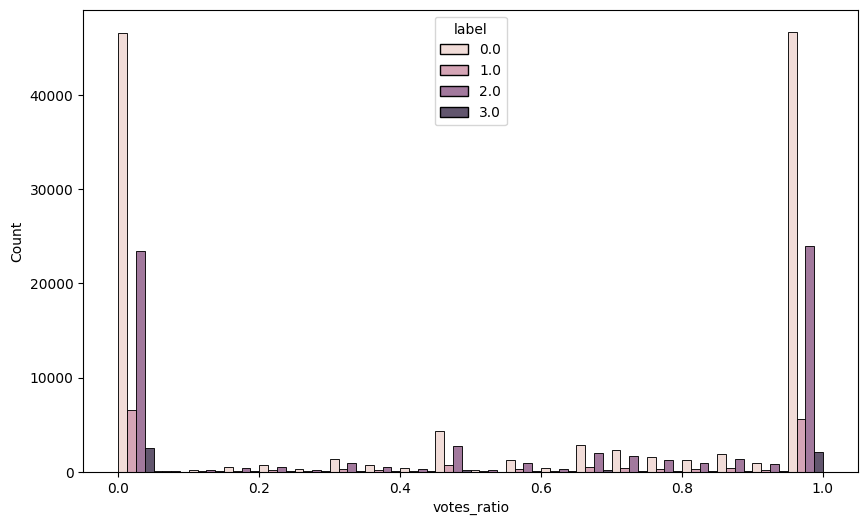

In [ ]:
plt.figure(figsize=(10, 6))
# A 1D histogram using hue to separate the labels - great for data clumps across diff labels
sns.histplot(data=df, x='votes_ratio', hue='label', bins=20, multiple='dodge')
plt.show()

<Axes: xlabel='label', ylabel='votes_ratio'>

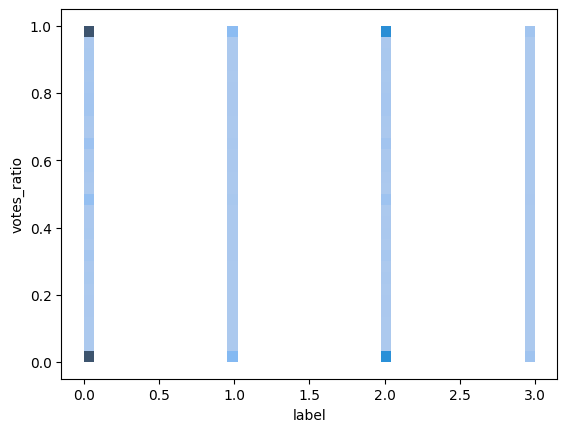

In [52]:
sns.histplot(x= 'label', y = 'votes_ratio', data = df)

### Vote Ratio vs label
1. the plot is almost uniform 
2. since the vast majority snaps to either 0 or 1 it means there's very huge amount of posts with low engagement (1/0+1=1) 
2. Mini spikes neat 0.5
3. for label 1 and 3 the meadian line is perfectly 0.5 - half of data lean towards 0 or 1
4. for label 0 and 2 the median line is higer ~0.66 the data favors +ve ratios as more than half of data is above 0.5 
5. very few comments have ratios between 0.2-0.5 or 0.8 - This confirms High column votes are rare as 4/4+1 = 0.2 

### Issues it'll face in modelling : 
Right now, votes_ratio is formatted as a continuous, numerical column (float). However, it does not actually behave like a continuous feature.
- Linear Models & Neural Networks: Algorithms like Logistic Regression or standard Neural Networks assume a smooth, continuous relationship. They will assume that a ratio of 0.5 is logically halfway between 0.0 and 1.0. But in your dataset, 0.5 might represent a highly controversial comment with 100 votes, while 0.0 and 1.0 represent ignored comments with just 1 vote. The model will get very confused by this logic.

- Tree-Based Models: Algorithms like Random Forest, XGBoost, or LightGBM will handle this much better. They can make hard splits (e.g., if votes_ratio == 1.0) and essentially treat those extreme spikes as their own distinct categories.

<Axes: xlabel='label', ylabel='engagement_score'>

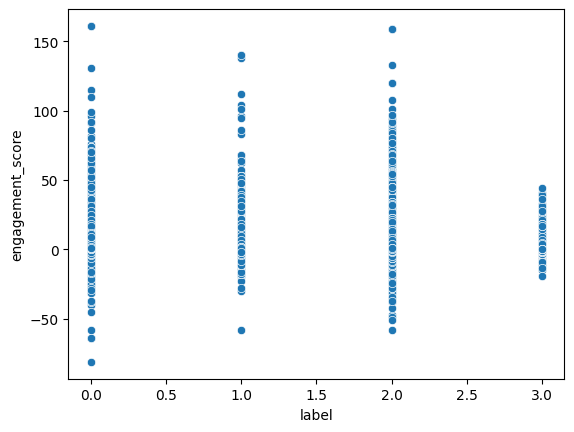

In [14]:
# sns.boxplot(x='label', y='engagement_score', data=df)
sns.scatterplot(x='label', y='engagement_score', data=df)

### Engagement Score vs Label
1. data is really skewed
2. vast majority of data is concentrated near zero
3. Have fat tails (heavy outliers)
4. although it's not very clear yet just from the looks it's seems like 
    - label 0 and 2 have the highest amount of +ve engagement
    - label 3.0 is much constrained, lack the wild virality and maxim at around 50

Note: 
If you feed this engagement_score as a feature or target directly into certain models (especially distance-based ones like KNN or linear models like Logistic/Linear Regression), those extreme outliers will heavily distort your model's weights. The model will spend all its effort trying to account for the viral anomalies and perform poorly on the vast majority of normal data.

<Axes: xlabel='label', ylabel='num_!'>

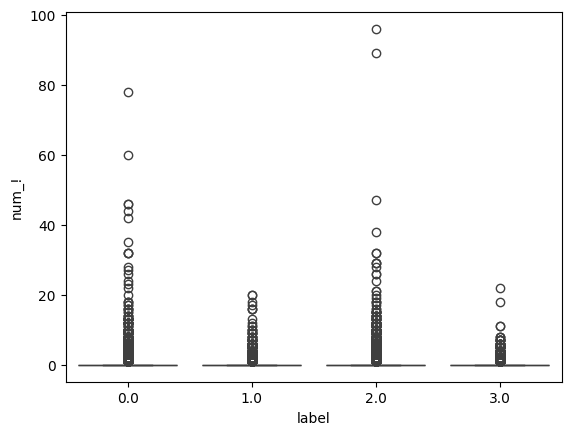

In [77]:
sns.boxplot(x='label', y='num_!', data=df)
# sns.violinplot(x='label', y='num_!', data=df)

1. they are all sitting on zero, it means at least 75% of all comments in your dataset contain absolutely zero exclamation marks.


<Axes: xlabel='label', ylabel='num_ques'>

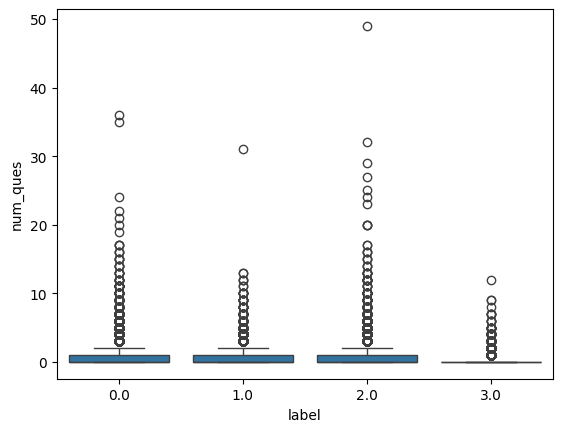

In [74]:
sns.boxplot(x='label', y='num_ques', data=df)


<Axes: xlabel='sentiment_vader', ylabel='Count'>

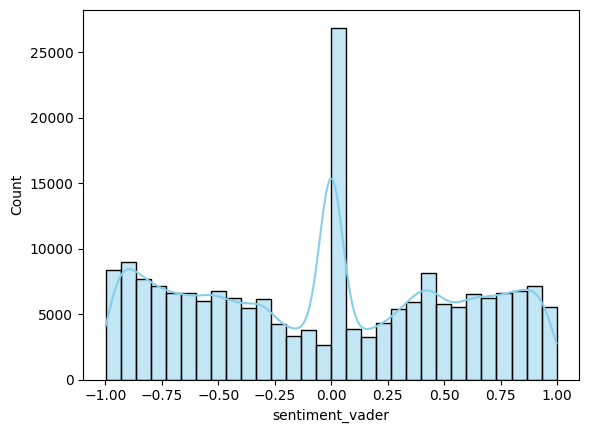

In [63]:
sns.histplot(data=df, x='sentiment_vader', bins=30, kde=True, color='skyblue')

<Axes: xlabel='label', ylabel='sentiment_vader'>

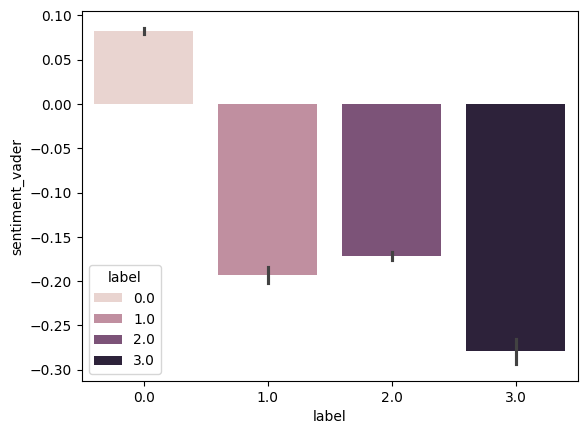

In [47]:
sns.barplot(data = df, x = 'label', y = 'sentiment_vader', hue='label')

### Obeservation : Sentiment vs label
1. The bar for label 0.0 is the only one sitting above the zero line (averaging around +0.08). means comments in this category are generally positive, polite, or constructive
2. label 3 is the Highly Toxic or Angry Class as the bar plunges nearly -28, making it most negative category meaning these comments are likely highly aggressive, containing strong insults, swearing, or intense negative emotion.
3. labels 1.0 and 2.0 both sit around -0.17 to -0.19, 

### Emotional Obsevation: num_ques vs label and num_! vs label

1. The "Punctuation Spammers" (Labels 0.0 and 2.0)

    Just like we saw in the comment length plots, Labels 0.0 and 2.0 are where the extreme behavior lives.

- The Exclamation Outliers: Someone in Label 2.0 used nearly 100 exclamation marks in a single comment! Label 0.0 isn't far behind, hitting around 80.

- The Question Outliers: Similarly, users in Labels 0.0 and 2.0 are dropping up to 50 question marks at a time.

- What this means: These classes contain highly expressive, possibly angry, confused, or spammy comments. This is a fantastic signal for classification.

2. Label 3.0 Remains the "Quiet" Category
This lines up perfectly with the violin plot from earlier. Label 3.0 had the shortest comments, and here we see they also use the least punctuation. Their exclamation marks cap out around 20, and question marks barely pass 10.

<Axes: xlabel='created_hour', ylabel='count'>

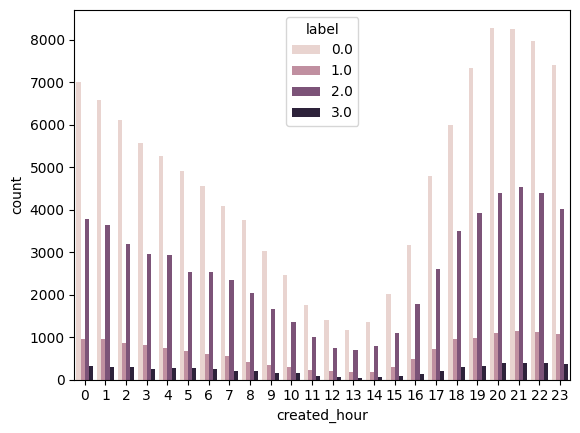

In [78]:
sns.countplot(x='created_hour', hue='label', data=df)

### Observations: hour vs label
1. **Night Owl Supremacy!** 
2. best timer ranges between 7-9pm and stay high well past midnight
3. most probably users are scrolling and commenting primarily during evening and late night hours..
4. pretty much all the labels follow exact same curve.. means that more comments in the time frame are general - thus won't help much in prediction

Note: Might have to to time binning 

<Axes: xlabel='weekday', ylabel='count'>

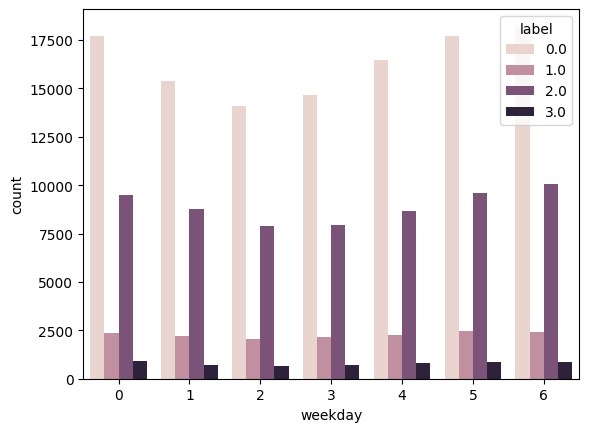

In [86]:
sns.countplot(x='weekday', hue='label', data=df) #0 represents Monday and 6 represents Sunday

<Axes: xlabel='weekend', ylabel='count'>

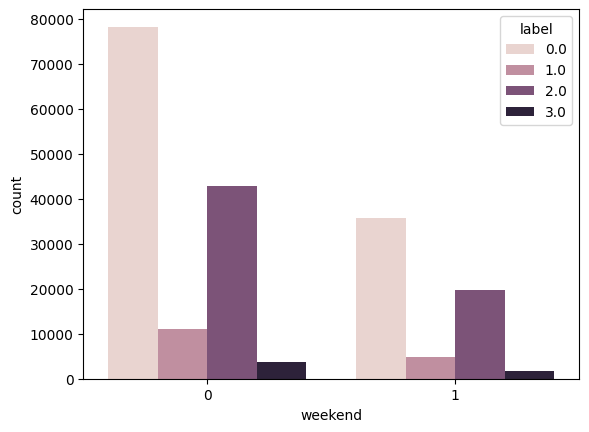

In [87]:
sns.countplot(x='weekend', hue='label', data=df) #0 represents Monday and 6 represents Sunday

### Weekday vs Label
- The Highs: Days 0, 5, and 6 (Monday, Saturday, Sunday) show the highest volume of comments.

- The Lows: Activity distinctly dips in the middle of the week, hitting rock bottom on Day 2 (Wednesday).

- The Insight: Your users are most active on the weekends and immediately at the start of the work/school week, likely dropping off mid-week when they are busiest.

There's a jump from weekend to weekday: sun to mon; people comment more on after weekends

1. The Volume Illusion (5 Days vs. 2 Days)
At first glance, it looks like weekday activity (0) absolutely crushes weekend activity (1), with the bars being roughly twice as high.

- Label 0.0 has about 78,000 comments on weekdays vs. about 36,000 on weekends.

- The Catch: A weekday bucket contains 5 days of data, while the weekend bucket only contains 2 days.

- The Insight: If you divide 78,000 by 5, you get roughly 15,600 comments per day. If you divide 36,000 by 2, you get 18,000 comments per day. Your users are actually more active per day on the weekend! The raw count just looks smaller because it's a shorter time window.

2. The shape of the staircase in bucket 0 is absolutely identical to the shape in bucket 1. The ratios between Labels 0.0, 1.0, 2.0, and 3.0 do not change at all when the weekend hits.

Finale:
The ultimate conclusion from all three plots is that user behavior is incredibly consistent over time. While total traffic goes up and down, the type of comments (the labels) stays perfectly steady.

<Axes: xlabel='label', ylabel='post_comments_count'>

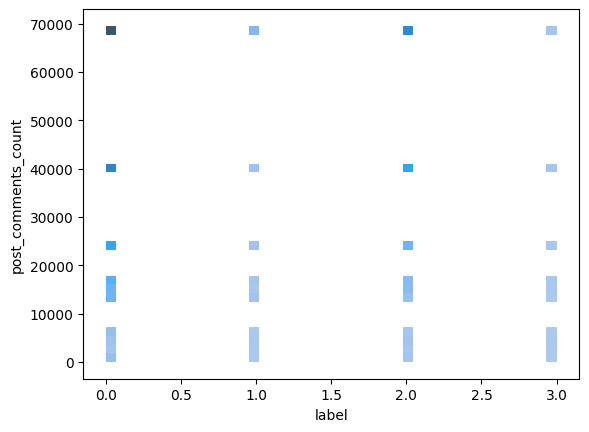

In [90]:
sns.histplot(x='label', y='post_comments_count', data=df)

### label vs post_comments_count
![Drop this col]

1. The identical Boxes - no predictive power
2. why: 
    - The 25th percentiles (bottom of the boxes), the medians (middle lines), and the 75th percentiles (top of the boxes) align perfectly across all classes.

    - The Machine Learning Reality: If a model looks at a row and sees post_comments_count = 41000 (the median), it has absolutely no idea if that row is a 0.0, 1.0, 2.0, or 3.0. The feature provides zero discriminatory power to separate your classes. Keeping it in your dataset will only add unnecessary complexity and memory usage.

3. The 2D histogram (the second plot) explains why the boxes look so identical. Notice how the data is clumped into perfectly horizontal, disconnected bands (around 7,000, 15,000, 25,000, 40,000, and a massive dark one right at 69,000).
    - Because a single mega post with 69,000 comments naturally generates a mix of all four labels (some positive, some negative, some neutral), the label distribution for that massive bucket of comments perfectly mirrors the overall dataset.

<Axes: xlabel='gender'>

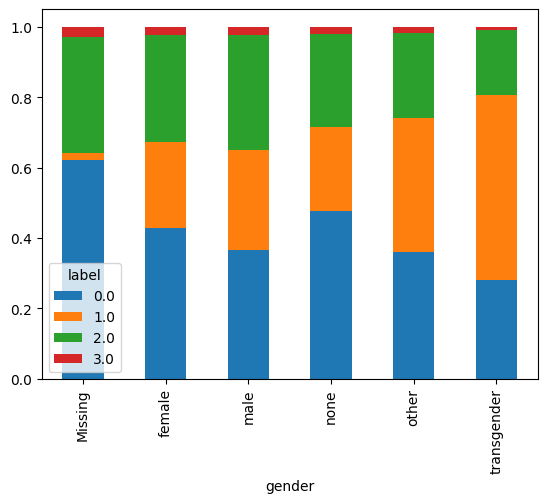

In [92]:
pd.crosstab(df['gender'], df['label'], normalize='index').plot(kind='bar', stacked=True)

### Gender vs label
1. missing baseline;; missing is dominated by 0(blue) and 2
2. transgender is dominated by label 1 and least by label 3
3. orange spikes from nothing in missing to taking 25-50% in distribution
    - means: whatever label 1 is its' perhaps identity attack or controversial or specific type of engagement **It's heavily trigged the moment gender identity is involved or even mentioned**

since we have isolated the missing ones in actual final dataset it'd be of help in analysis

In [64]:
df.columns

Index(['Unnamed: 0', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment',
       'label', 'is_train', 'weekday', 'weekend', 'created_hour',
       'race_missing', 'religion_missing', 'gender_missing', 'comment_len',
       'word_cnt', 'num_!', 'num_ques', 'emoji_counts', 'votes_ratio',
       'upvote_log1', 'downvote_log1', 'engagement_score', 'emoticon_density',
       'post_comments_count', 'if_1_log', 'if_2_log', 'if_interaction_log',
       'sentiment_vader'],
      dtype='str')

In [95]:
df['if_interaction_sentiment'] = df['if_interaction_log'] * df['sentiment_vader']

<Axes: >

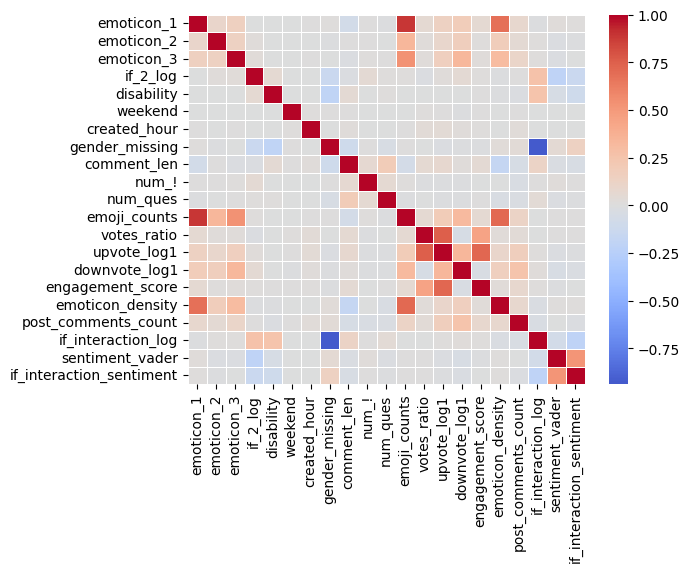

In [96]:
numerical_col = ['emoticon_1', 'emoticon_2', 'emoticon_3', 
                'if_2_log','disability', 'weekend', 'created_hour',
                'gender_missing', 'comment_len',
                'num_!', 'num_ques', 'emoji_counts', 'votes_ratio', 'upvote_log1',
                'downvote_log1', 'engagement_score', 'emoticon_density',
                'post_comments_count', 'if_interaction_log',
                'sentiment_vader','if_interaction_sentiment'] #excluded: ['post_id', 'comments'(in tf-idf), word_cnt,'race_missing', 'religion_missing', 'if_1', 'if_2', 'if_1_log']

corr = df[numerical_col].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
# This plot is designed to hunt down a specific enemy in machine learning: Multicollinearity (when two or more features provide the exact same information).

# # 3. Plot with extra formatting
# plt.figure(figsize=(10, 8))
# sns.heatmap(corr,         # Shows the numbers in the boxes
#             fmt=".2f",           # Rounds to 2 decimal places
#             cmap='coolwarm',     # Your chosen color scheme
#             center=0,            # Ensures 0 is the neutral color
#             linewidths=.5)       # Adds small gaps between squares

# plt.title('Correlation Heatmap')
# plt.show()

### Heat Map Analysis
1. The missing data block in the middle, since they're perfectly correlated that means is a user didn't provide their race or any other two[gender, religion] means they didn't provide other 3 as well.. 
    - Keeping all three won't give any new informations, thus keep any 1 and drop other two
2. If you notice *comment_len* and *word_cnt* are almost almost itentical(same gradient) - can drop 1 or 2
    - Also if notice there's a red block in middle: more words -> higer charecter length
    - Drop: *word_cnt* is is better to keep helps with nlp as kinda like tokens
3. Engagement clusters near right bottom - upvote_log1, engagement_score, vote_ratio
    - that means that since engagement scores and ratios are mathematically calculated using the raw upvote/downvote counts, they are highly dependent on each other.
4. correlation between emoticon_1, emoji_counts, and emoticon_density
    - If someone uses a lot of emojis overall (emoji_counts), they naturally have a higher emoticon_density and are highly likely to have triggered whatever specific emoji emoticon_1 represents.
5. As we had guess above *weekend* and *weekday* interset - as we can drop either; drop weekday
6. Since these 'if_1', 'if_2', 'if_1_log', 'if_2_log' and 'if_interaction_log' were heavly correlated so to avoid feature bloating i've decided to keep only 'if_2_log' and 'if_interaction_log'

7. if we notice a blue cell bwt if_interaction_log and sentiment_vader is the only string negative correlation in the matrix rest everything is either red(positive) or white(no relationship). Lgbm already learn the high interaction and negative sentiment is label 3.0 but it'll take 2-3 levels to get so why not create a interation term the encodes the joint patter in single col.(if_interaction_sentiment). The model can now learn that in one split instead of two, which means it needs fewer trees and learns it more reliably.

# **Note:**

After seeing and analysing the visualisation there are a few changes to make in the dataset inorder to have a smooth model training.. so refer the final_eda.py file.

In [94]:
df.columns

Index(['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2',
       'race', 'religion', 'gender', 'disability', 'comment', 'label',
       'is_train', 'weekday', 'weekend', 'created_hour', 'race_missing',
       'religion_missing', 'gender_missing', 'comment_len', 'word_cnt',
       'num_!', 'num_ques', 'emoji_counts', 'votes_ratio', 'upvote_log1',
       'downvote_log1', 'engagement_score', 'emoticon_density',
       'post_comments_count'],
      dtype='str')